# Principal Component Analysis (PCA) — Personality Structure in BFI-2 Data

## What is PCA?

**Principal Component Analysis (PCA)** is an unsupervised dimensionality reduction technique. It finds new axes (principal components) that capture the **maximum variance** in the data, expressed as linear combinations of the original features.

Each principal component is **orthogonal** (uncorrelated) to the others, and they are ordered by how much variance they explain.

### Why PCA on personality data?
- The Big Five traits + OCB + CWB are correlated — PCA reveals the **underlying structure**
- Reduces 7 variables to 2–3 components for **visualization**
- The **biplot** shows which traits cluster together and drive variance
- Provides a reduced feature space for K-Means and DBSCAN (see next notebooks)
- Answers: *Do OCB and CWB align with specific personality dimensions?*

### Pipeline
```
Big Five traits + OCB + CWB (7 variables)
        ↓
StandardScaler (z-score normalize)
        ↓
PCA (fit on all 7 components)
        ↓
Scree plot → choose number of components
        ↓
2D/3D visualization + biplot
        ↓
Reduced coordinates saved for K-Means & DBSCAN
```

## 1. Preprocessing data, import require packages, prepare features for PCA

**Big Five trait scores + OCB + CWB** are applied as the feature set. These are all on the same 1–5 scale, but they are still standardize to ensure PCA is not driven by differences in variance rather than differences in meaning.

In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports complete")

repo_root = Path.cwd().resolve()
while not (repo_root / "BFI_2_life_narative_metadata.json").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find BFI_2_life_narative_metadata.json")
    repo_root = repo_root.parent

# Load data
with open(repo_root / "BFI_2_life_narative_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(repo_root / "BFI_2_life_narrative.json", "r", encoding="utf-8") as f:
    responses = json.load(f)

df = pd.DataFrame(responses)

# Reverse-code BFI items
reverse_items = metadata["reverse_code_items"]

for item in reverse_items:
    if item in df.columns:
        df[item] = 6 - df[item]

# Big Five trait means
traits = {
    key: value
    for key, value in metadata.items()
    if (
        isinstance(value, list)
        and value
        and isinstance(value[0], str)
        and value[0].startswith("Item")
        and not key.startswith(("Item", "Q", "CWB", "OCB"))
        and key != "reverse_code_items"
    )
}

for trait, items in traits.items():
    available_items = [item for item in items if item in df.columns]
    df[trait] = df[available_items].mean(axis=1)

# CWB and OCB means
cwb_cols = [f"CWB{i}" for i in range(1, 11) if f"CWB{i}" in df.columns]
ocb_cols = [f"OCB{i}" for i in range(1, 11) if f"OCB{i}" in df.columns]

df["CWB"] = df[cwb_cols].mean(axis=1)
df["OCB"] = df[ocb_cols].mean(axis=1)

# pull features
features = ["Extraversion", "Agreeableness", "Conscientiousness",
            "Neuroticism", "Openness", "OCB", "CWB"]

# drop any rows where trait/OCB/CWB scores are missing
X_raw = df[features].dropna().reset_index(drop=True)

# carry ID if it exists, for reference
ids = df.loc[df[features].dropna().index, "ID"].reset_index(drop=True) \
     if "ID" in df.columns else X_raw.index

# standardize: mean=0, std=1
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Samples : {X_scaled.shape[0]}")
print(f"Features: {X_scaled.shape[1]} → {features}")
print("\nMean after scaling (should be ~0):")
print(X_scaled.mean(axis=0).round(4))
print("\nStd after scaling (should be ~1):")
print(X_scaled.std(axis=0).round(4))

✓ Imports complete
Samples : 500
Features: 7 → ['Extraversion', 'Agreeableness', 'Conscientiousness', 'Neuroticism', 'Openness', 'OCB', 'CWB']

Mean after scaling (should be ~0):
[-0.  0. -0. -0.  0. -0.  0.]

Std after scaling (should be ~1):
[1. 1. 1. 1. 1. 1. 1.]


## 2. Fit PCA — All Components

Fit PCA retaining **all 7 components** to see how much variance each one explains before deciding how many to keep.

In [3]:
pca_full = PCA(n_components=len(features), random_state=42)
pca_full.fit(X_scaled)

explained       = pca_full.explained_variance_ratio_
cumulative      = np.cumsum(explained)
component_names = [f"PC{i+1}" for i in range(len(features))]

print("Explained variance per component:")
for name, ev, cv in zip(component_names, explained, cumulative):
    print(f"  {name}: {ev*100:.2f}%  (cumulative: {cv*100:.2f}%)")

Explained variance per component:
  PC1: 33.88%  (cumulative: 33.88%)
  PC2: 20.94%  (cumulative: 54.82%)
  PC3: 14.01%  (cumulative: 68.84%)
  PC4: 10.33%  (cumulative: 79.17%)
  PC5: 8.05%  (cumulative: 87.22%)
  PC6: 7.31%  (cumulative: 94.53%)
  PC7: 5.47%  (cumulative: 100.00%)


## 3. Choosing number of components

The **scree plot** shows the explained variance per component. Attention is focused on the **elbow** — the point where adding more components gives diminishing returns.

The **cumulative variance line** shows how many components are needed to explain a given percentage of total variance. A common threshold is **80%**.

The scree plot revealed that the first four principal components collectively 
explained **79.2% of total variance** (PC1: 33.9%, PC2: 20.9%, PC3: 14.0%, 
PC4: 10.3%), close to the conventional 80% threshold. These four components 
were retained for downstream clustering analyses (K-Means and DBSCAN).

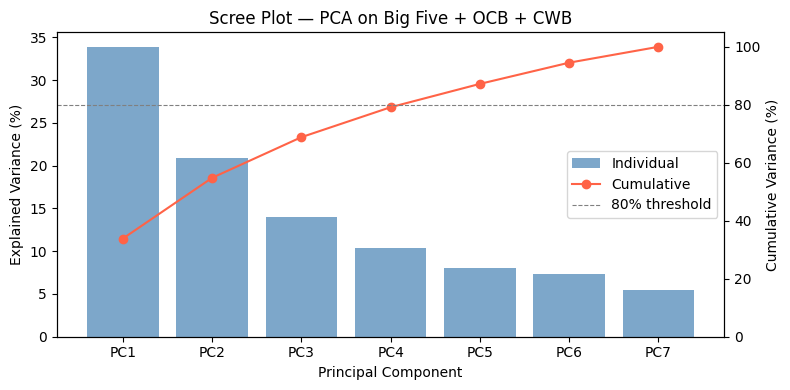

Components needed for 80% variance: 5


In [4]:
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.bar(component_names, explained * 100, color="steelblue", alpha=0.7, label="Individual")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_xlabel("Principal Component")
ax1.set_title("Scree Plot — PCA on Big Five + OCB + CWB")

ax2 = ax1.twinx()
ax2.plot(component_names, cumulative * 100, marker="o", color="tomato", label="Cumulative")
ax2.axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80% threshold")
ax2.set_ylabel("Cumulative Variance (%)")
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.show()

# Print how many components to reach 80%
n_80 = np.argmax(cumulative >= 0.80) + 1
print(f"Components needed for 80% variance: {n_80}")

## 4. 2 components for visualization

**2 PCA components** are used for 2D visualization. This gives a map of every participant in "personality space" — people who are close together have similar trait profiles.

In [5]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca2, columns=["PC1", "PC2"])
pca_df["OCB"] = X_raw["OCB"].values
pca_df["CWB"] = X_raw["CWB"].values

print(f"PC1 explains: {pca2.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explains: {pca2.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total        : {pca2.explained_variance_ratio_.sum()*100:.2f}%")
pca_df.head()

PC1 explains: 33.88%
PC2 explains: 20.94%
Total        : 54.82%


,PC1,PC2,OCB,CWB
0,-0.901171,0.795643,3.2,1.7
1,2.470438,-0.571106,2.7,1.1
2,-0.480755,2.101189,3.6,2.1
3,0.918471,0.222564,2.8,1.5
4,-0.743472,-0.168839,2.8,1.5


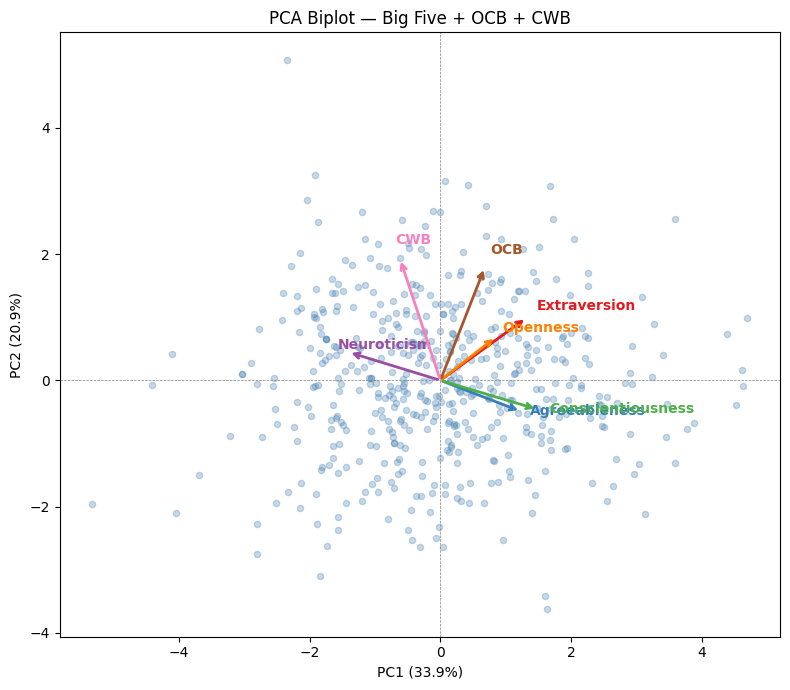

In [10]:
loadings = pca2.components_.T  # shape: (n_features, 2)
scale    = 3.0                 # scale arrows for visibility

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.3, s=20, color="steelblue", label="Participants")

colors_arrow = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628", "#f781bf"]
for i, (feature, color) in enumerate(zip(features, colors_arrow)):
    ax.annotate("",
        xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=color, lw=2)
    )
    ax.text(loadings[i, 0] * scale * 1.12,
            loadings[i, 1] * scale * 1.12,
            feature, fontsize=10, color=color, fontweight="bold")

ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA Biplot — Big Five + OCB + CWB")
plt.tight_layout()
plt.show()

### Biplot Interpretation

The PCA biplot (Figure X) displays participants as points in the two-dimensional 
space defined by PC1 and PC2, with arrows representing the direction and magnitude 
of each variable's contribution to these components.

**PC1 — Adjustment Dimension (33.9%)**  
A clear directional split is visible along the PC1 axis. Conscientiousness, 
Agreeableness, Extraversion, and Openness project to the right (+PC1), while 
Neuroticism and CWB project to the left (−PC1). This pattern reflects a broad 
psychological adjustment dimension: participants on the right of the plot tend 
toward adaptive, organized, and sociable profiles, while those on the left show 
higher emotional instability and counterproductive behavior.

**PC2 — Behavioral Engagement Dimension (20.9%)**  
The most notable finding in the biplot is that both OCB and CWB arrows project 
upward in the same direction along PC2, despite representing behaviorally opposite 
constructs. This suggests that OCB and CWB share a common variance component — 
potentially reflecting overall **behavioral activation or engagement** — 
independent of whether the behavior is prosocial or counterproductive. This finding 
is consistent with research suggesting that high-activation individuals tend to 
engage more in all types of discretionary workplace behavior (Spector & Fox, 2010).

**Arrow angles and correlations**  
Conscientiousness and Agreeableness point in nearly identical directions, 
indicating a strong positive correlation between these traits in this sample. 
Neuroticism points in the near-opposite direction from Conscientiousness, 
consistent with their well-established negative relationship in the Big Five 
literature. Notably, OCB and Conscientiousness form approximately a 90° angle, 
suggesting these two variables are largely uncorrelated in this sample — an 
unexpected finding given that Conscientiousness is typically the strongest 
Big Five predictor of OCB.

**Participant distribution**  
The participant scatter forms a diffuse, roughly elliptical cloud with no visible 
gaps or discrete groupings, visually confirming that personality variation in 
this sample is **continuously distributed**. 

## 5. Component composition

The **loadings matrix** shows exactly how much each original variable contributes to each principal component. Positive values mean the variable increases along that component; negative values mean it decreases.

PCA Loadings (first 4 components):
                     PC1    PC2    PC3    PC4
Extraversion       0.439  0.330 -0.238 -0.335
Agreeableness      0.410 -0.164  0.310  0.666
Conscientiousness  0.495 -0.153 -0.085 -0.074
Neuroticism       -0.469  0.149  0.500  0.113
Openness           0.283  0.228  0.740 -0.465
OCB                0.227  0.596  0.009  0.456
CWB               -0.206  0.641 -0.206  0.040


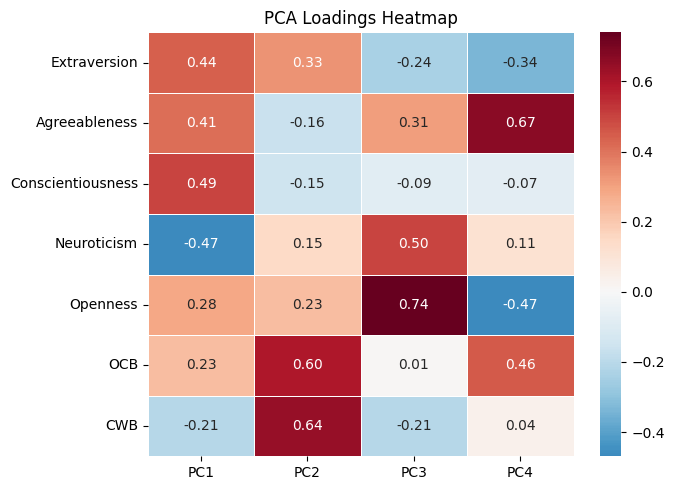

In [8]:
loadings_df = pd.DataFrame(
    pca_full.components_[:4].T,   # show first 4 PCs
    index=features,
    columns=[f"PC{i+1}" for i in range(4)]
).round(3)

print("PCA Loadings (first 4 components):")
print(loadings_df)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(loadings_df, annot=True, cmap="RdBu_r", center=0,
            fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("PCA Loadings Heatmap")
plt.tight_layout()
plt.show()

**PC1 — Positive Adjustment (33.9% variance)**  
PC1 contrasts positive personality traits against negative/counterproductive ones.
High positive loadings on Conscientiousness (0.495), Extraversion (0.439), and 
Agreeableness (0.410) oppose strong negative loadings on Neuroticism (−0.469) and 
CWB (−0.206). This component broadly reflects a **well-adjusted vs. 
stress-prone/counterproductive** dimension, consistent with the established 
relationship between Neuroticism, low Conscientiousness, and counterproductive 
workplace behavior in the organizational psychology literature.

**PC2 — Prosocial Engagement (20.9% variance)**  
PC2 is dominated by high positive loadings on CWB (0.641) and OCB (0.596), with 
moderate contributions from Extraversion (0.330) and Openness (0.228). Notably, 
both OCB and CWB load in the **same direction** on PC2, suggesting that 
behavioral engagement at work — whether prosocial or counterproductive — shares 
a common dimension, possibly reflecting overall behavioral activation or 
extraversion-driven engagement rather than valence.

**PC3 — Openness/Neuroticism (14.0% variance)**  
PC3 is primarily driven by Openness (0.740) and Neuroticism (0.500), capturing 
individual differences in intellectual curiosity and emotional reactivity 
independent of the first two components.

**PC4 — Agreeableness/OCB (10.3% variance)**  
PC4 contrasts Agreeableness (0.666) and OCB (0.456) against Openness (−0.465) 
and Extraversion (−0.335), potentially distinguishing cooperative/compliant 
individuals from those who are independently minded.

## 6. Save PCA coordinates for K-Means and DBSCAN

We save the 2D PCA coordinates so that K-Means and DBSCAN notebooks can import them directly without re-running PCA.

In [9]:
# Use 4 components — captures 79.17% variance (just under 80% threshold)
N_COMPONENTS = 4

pca_final = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca_final = pca_final.fit_transform(X_scaled)

# Build save dataframe
pca_coords = pd.DataFrame(
    X_pca_final,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)]
)

# Keep 2D coords separately for visualization
pca_coords["PC1_vis"] = X_pca2[:, 0]   # from your 2-component PCA already fitted
pca_coords["PC2_vis"] = X_pca2[:, 1]

# Keep original features for cluster profiling
pca_coords[features] = X_raw.reset_index(drop=True)

pca_coords.to_csv(repo_root / "pca_coords.csv", index=False)
print(f"✓ Saved {N_COMPONENTS} PCA components ({pca_final.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"  Columns saved: {list(pca_coords.columns)}")
print(pca_coords.head())

✓ Saved 4 PCA components (79.2% variance)
  Columns saved: ['PC1', 'PC2', 'PC3', 'PC4', 'PC1_vis', 'PC2_vis', 'Extraversion', 'Agreeableness', 'Conscientiousness', 'Neuroticism', 'Openness', 'OCB', 'CWB']
        PC1       PC2       PC3       PC4   PC1_vis   PC2_vis  Extraversion  \
0 -0.901171  0.795643  2.562879  0.729266 -0.901171  0.795643      2.416667   
1  2.470438 -0.571106 -0.825172 -0.400484  2.470438 -0.571106      4.583333   
2 -0.480755  2.101189  0.425960  0.389883 -0.480755  2.101189      3.916667   
3  0.918471  0.222564 -0.856079  0.641140  0.918471  0.222564      4.666667   
4 -0.743472 -0.168839 -0.643926 -0.168148 -0.743472 -0.168839      2.916667   

   Agreeableness  Conscientiousness  Neuroticism  Openness  OCB  CWB  
0       4.250000           3.083333     4.500000  4.750000  3.2  1.7  
1       4.250000           4.250000     1.583333  3.833333  2.7  1.1  
2       3.916667           2.500000     3.500000  4.083333  3.6  2.1  
3       4.500000           3.083333 